# Task-02

Perform data cleaning and exploratory data analysis (EDA) on a dataset of your choice, such as the Titanic dataset from Kaggle. Explore the relationships between variables and identify patterns and trends in the data.

## CLEANING

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset from Seaborn
titanic_df = sns.load_dataset('titanic')

# Display the first 5 rows of the DataFrame
display(titanic_df.head())

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Check for missing values
print('Missing values per column:')
display(titanic_df.isnull().sum())

Missing values per column:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
# Explore unique values in categorical columns
print('\nUnique values for key categorical columns:')
for col in ['pclass', 'sex', 'embarked', 'class', 'who', 'deck', 'embark_town', 'alive', 'alone']:
    if col in titanic_df.columns:
        print(f"\nColumn '{col}':")
        display(titanic_df[col].value_counts(dropna=False))


Unique values for key categorical columns:

Column 'pclass':


pclass
3    491
1    216
2    184
Name: count, dtype: int64


Column 'sex':


sex
male      577
female    314
Name: count, dtype: int64


Column 'embarked':


...

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64


Column 'alive':


alive
no     549
yes    342
Name: count, dtype: int64


Column 'alone':


alone
True     537
False    354
Name: count, dtype: int64

In [10]:
# Impute 'age' with the median
titanic_df['age'].fillna(titanic_df['age'].median(), inplace=True)

# Impute 'embarked' and 'embark_town' with their modes
for col in ['embarked', 'embark_town']:
    if titanic_df[col].isnull().any():
        mode_val = titanic_df[col].mode()[0]
        titanic_df[col].fillna(mode_val, inplace=True)

# Drop the 'deck' column due to a large number of missing values
titanic_df.drop('deck', axis=1, inplace=True)

print('Missing values after imputation and dropping:')
display(titanic_df.isnull().sum())

Missing values after imputation and dropping:


C:\Users\dell\AppData\Local\Temp\ipykernel_8952\3487186027.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_df['age'].fillna(titanic_df['age'].median(), inplace=True)
C:\Users\dell\AppData\Local\Temp\ipykernel_8952\3487186027.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chai

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

## EXPLORATORY DATA ANALYSIS

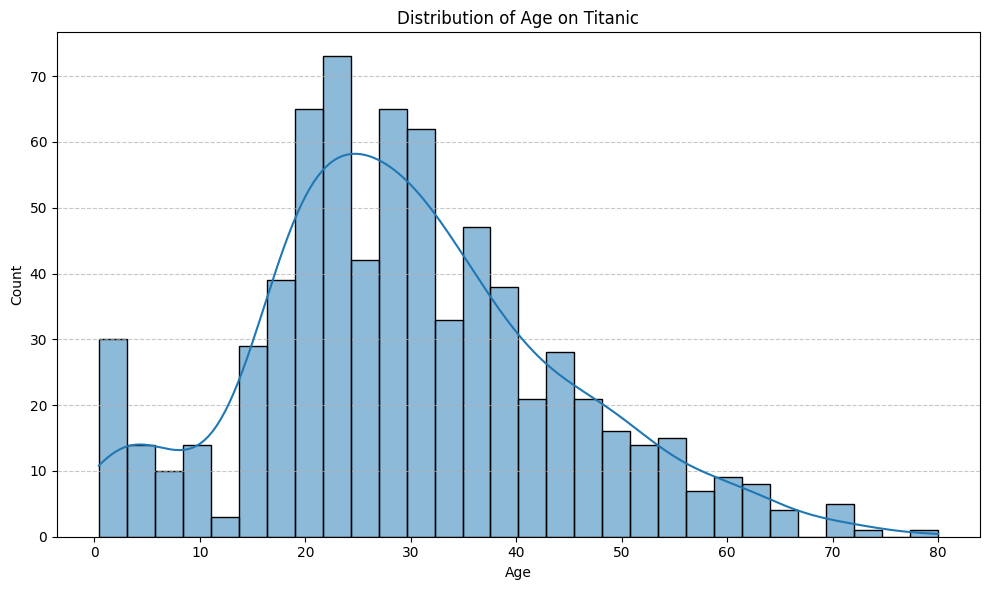

In [11]:
# Visualize distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(titanic_df['age'], kde=True, bins=30)
plt.title('Distribution of Age on Titanic')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

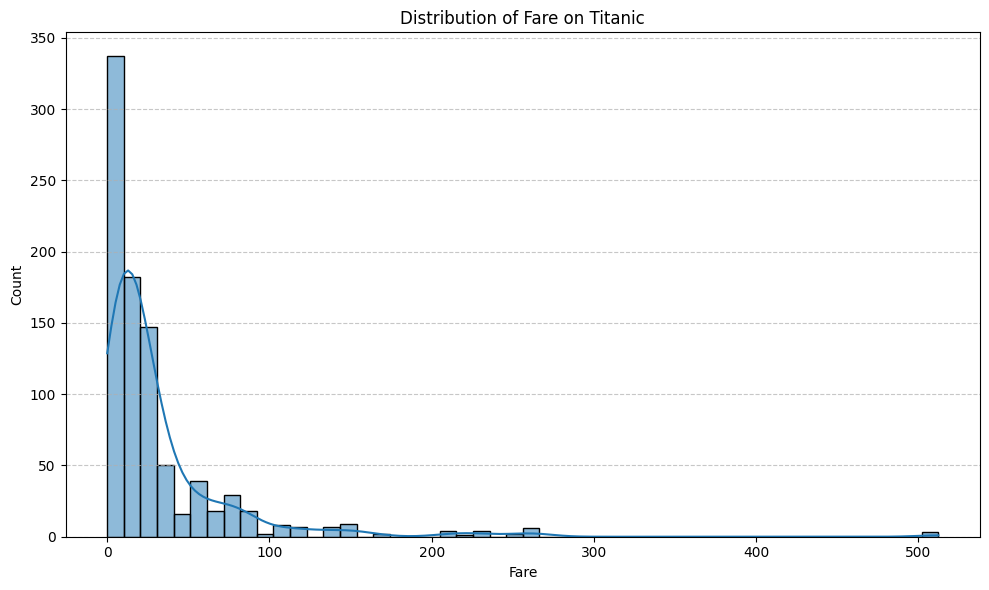

In [12]:
# Visualize distribution of 'fare'
plt.figure(figsize=(10, 6))
sns.histplot(titanic_df['fare'], kde=True, bins=50)
plt.title('Distribution of Fare on Titanic')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

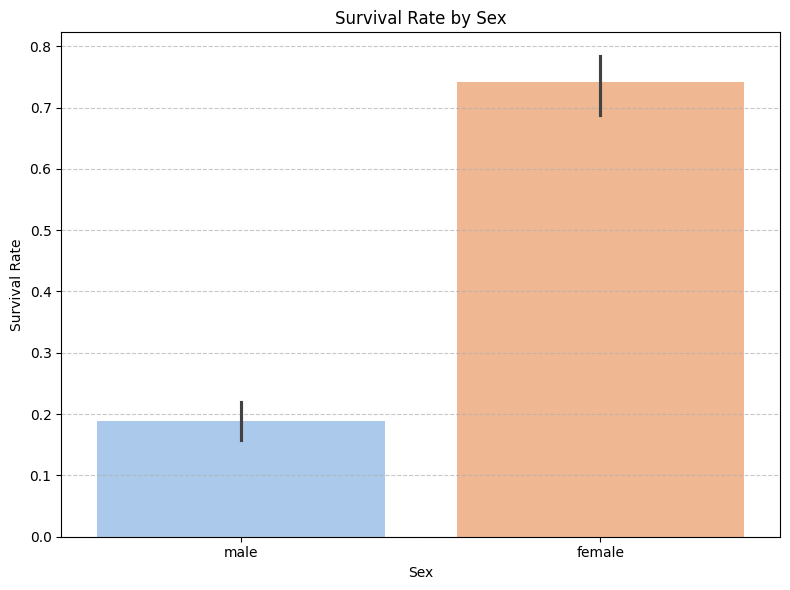

In [13]:
# Explore survival rate by 'sex'
plt.figure(figsize=(8, 6))
sns.barplot(x='sex', y='survived', data=titanic_df, palette='pastel', hue='sex', legend=False)
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

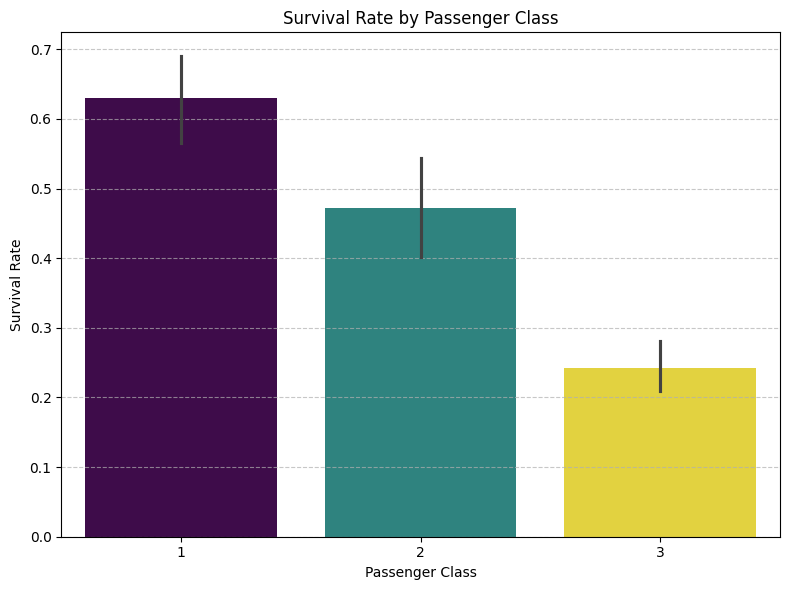

In [14]:
# Explore survival rate by 'pclass'
plt.figure(figsize=(8, 6))
sns.barplot(x='pclass', y='survived', data=titanic_df, palette='viridis', hue='pclass', legend=False)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()